### plot average waveforms

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, mannwhitneyu, wilcoxon, ttest_rel, ttest_ind
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import ColorConverter


PROJECT_PATH = os.getcwd()
proto_path = os.path.abspath(os.path.join(PROJECT_PATH, os.pardir))
neuro_path = os.path.abspath(os.path.join(proto_path, os.pardir))
pth = os.path.abspath(os.path.join(neuro_path, os.pardir))
sys.path.append(pth)
print(pth)

C:\Users\jud4011\AppData\Local\Temp\ipykernel_14544\1725946147.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


c:\Users\jud4011\Desktop\CODE\NSK-isolated\NSK-isolated


In [ ]:

# # groups = ['B6', 'NON', 'ANT']

# groups = ['NON']

# animals = ['NON-INT-03']

# # animals = ['B6_1M', 'B6_2M', 'B6_LEC1', 'B6_LEC2', 'ANT_119a_6', 'ANT_120_4', 'ANT_133a_4',
# #            'ANT_135a_7', 'ANT_140_4', 'NON_73_6', 'NON_88_1', 'NON_INT_01', 'NON_INT_02', 'NON_INT_03']

# # animals = ['B6-1M', 'B6-2M', 'B6-LEC1', 'B6-LEC2', 'ANT-119a-6', 'ANT-120-4', 'ANT-133a-4',
#         #    'ANT-135a-7', 'ANT-140-4', 'NON-73-6', 'NON-88-1', 'NON-INT-01', 'NON-INT-02', 'NON-INT-03']


# channels = ['ch1', 'ch2', 'ch3', 'ch4']


# folder_path = r"z:\Users\Andrew\LEC\all_LEC_data\all_animals\all_completed_copies (made by julian, for running avg waveform)\ANT-133a-4"

# avg_waveform_dict = {}
# missing_map_dict = {}

# for folder in os.listdir(folder_path):
#     # if 'missing' in folder.lower():
#     #     dict_to_use = missing_map_dict
#     # else:
#     #     dict_to_use = avg_map_dict
#     dict_to_use = avg_waveform_dict

#     if 'avgs' in folder.lower():
#         for group in groups:
#             print(f"group: {group}")

#             for channel in channels:
#                 if True:
#                     #load in group waveforms
#                     dict_to_use[group + '_' + channel + '_'+ 'waveforms'] = np.load(os.path.join(folder_path, folder, group + '_' + channel + '_' + 'waveforms' + '.npy'))

#                     #load in group distributions (large 1D array)
#                     dict_to_use[group + '_' + channel + '_'+ 'dist'] = np.load(os.path.join(folder_path, folder, group + '_' + channel + '_' + 'dist.npy'))

#                 for animal in animals:
#                     dict_to_use[animal + '_' + channel + '_'+ 'waveforms'] = np.load(os.path.join(folder_path, folder, animal + '_' + channel + '_'+ 'waveforms' +'.npy'))

#                     dict_to_use[animal + '_' + channel + '_'+ 'dist'] = np.load(os.path.join(folder_path, folder, animal + '_' + channel + '_'+ 'dist.npy'))

In [4]:

# groups = ['B6', 'NON', 'ANT']

# groups = ['NON']



# animals = ['B6_1M', 'B6_2M', 'B6_LEC1', 'B6_LEC2', 'ANT_119a_6', 'ANT_120_4', 'ANT_133a_4',
#            'ANT_135a_7', 'ANT_140_4', 'NON_73_6', 'NON_88_1', 'NON_INT_01', 'NON_INT_02', 'NON_INT_03']

# animals = ['B6-1M', 'B6-2M', 'B6-LEC1', 'B6-LEC2', 'ANT-119a-6', 'ANT-120-4', 'ANT-133a-4',
        #    'ANT-135a-7', 'ANT-140-4', 'NON-73-6', 'NON-88-1', 'NON-INT-01', 'NON-INT-02', 'NON-INT-03']


channels = ['ch1', 'ch2', 'ch3', 'ch4']

animals = ['B6-1M']

folder_path = r"z:\Users\Andrew\LEC\all_LEC_data\all_animals\all_completed_copies (made by julian, for running avg waveform)\B6-1M"

avg_waveform_dict = {}
missing_map_dict = {}

for folder in os.listdir(folder_path):
    # if 'missing' in folder.lower():
    #     dict_to_use = missing_map_dict
    # else:
    #     dict_to_use = avg_map_dict
    dict_to_use = avg_waveform_dict

    if 'avgs' in folder.lower():
        # for group in groups:
        #     print(f"group: {group}")

        for channel in channels:
            # if True:
            #     #load in group waveforms
            #     dict_to_use[group + '_' + channel + '_'+ 'waveforms'] = np.load(os.path.join(folder_path, folder, group + '_' + channel + '_' + 'waveforms' + '.npy'))

            #     #load in group distributions (large 1D array)
            #     dict_to_use[group + '_' + channel + '_'+ 'dist'] = np.load(os.path.join(folder_path, folder, group + '_' + channel + '_' + 'dist.npy'))

            for animal in animals:
                dict_to_use[animal + '_' + channel + '_'+ 'waveforms'] = np.load(os.path.join(folder_path, folder, animal + '_' + channel + '_'+ 'waveforms' +'.npy'))

                dict_to_use[animal + '_' + channel + '_'+ 'dist'] = np.load(os.path.join(folder_path, folder, animal + '_' + channel + '_'+ 'histogram.npy'), allow_pickle=True).item()


In [5]:
for i, k in enumerate(sorted(avg_waveform_dict.keys())):
    print(f"{i}: {k}")

0: B6-1M_ch1_dist
1: B6-1M_ch1_waveforms
2: B6-1M_ch2_dist
3: B6-1M_ch2_waveforms
4: B6-1M_ch3_dist
5: B6-1M_ch3_waveforms
6: B6-1M_ch4_dist
7: B6-1M_ch4_waveforms



B6-1M_ch1:
  Bin range: -150.00 to 150.00 µV, total values: 700600300
  Bin for  128 µV: 0 values
  Bin for -128 µV: 15,898,706 values
  Bin for  127 µV: 7,837,880 values
  Bin for -127 µV: 174,266 values
  >>> Values < -128 µV: 0 (0.00%)
  >>> Values > 128 µV: 0 (0.00%)
  >>> Total beyond ±128: 0 (0.00%)
  >>> Bins for values < -128 µV (edge_low, edge_high, count):
      (none)
  >>> Bins for values > 128 µV (edge_low, edge_high, count):
      (none)

B6-1M_ch2:
  Bin range: -150.00 to 150.00 µV, total values: 700600300
  Bin for  128 µV: 0 values
  Bin for -128 µV: 3,874,168 values
  Bin for  127 µV: 5,333,426 values
  Bin for -127 µV: 75,873 values
  >>> Values < -128 µV: 0 (0.00%)
  >>> Values > 128 µV: 0 (0.00%)
  >>> Total beyond ±128: 0 (0.00%)
  >>> Bins for values < -128 µV (edge_low, edge_high, count):
      (none)
  >>> Bins for values > 128 µV (edge_low, edge_high, count):
      (none)

B6-1M_ch3:
  Bin range: -150.00 to 150.00 µV, total values: 700600300
  Bin for  128 µV

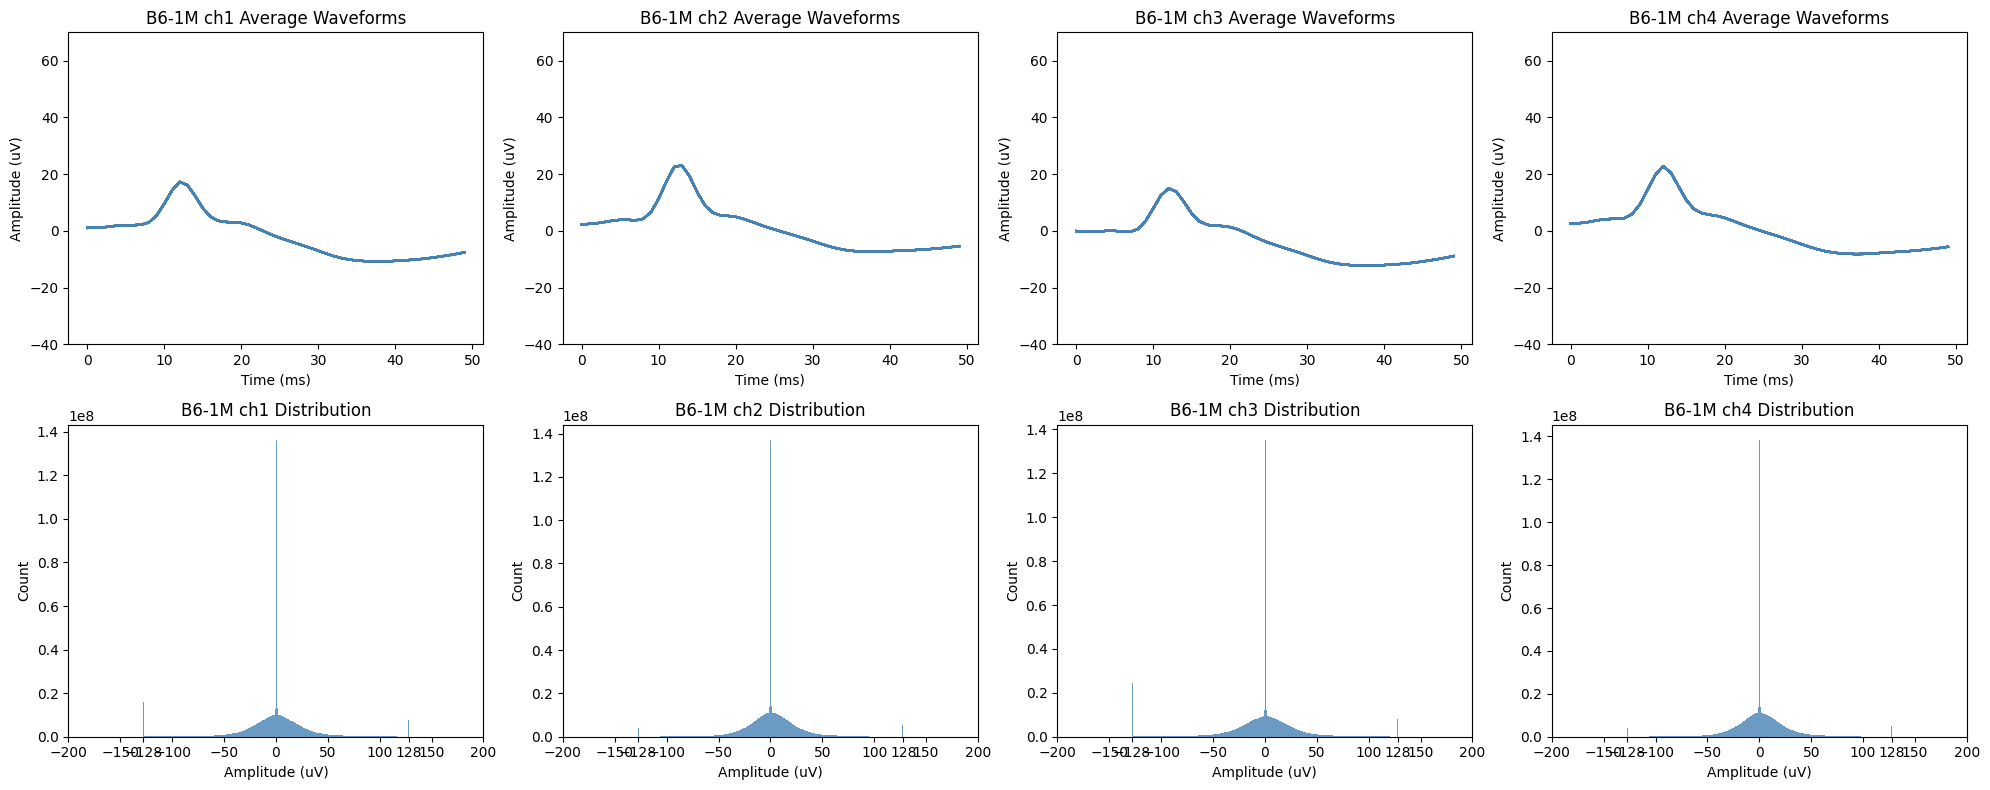

In [12]:
# NON_animals = ['NON-73-6', 'NON-88-1', 'NON-INT-01', 'NON-INT-02', 'NON-INT-03']

# NON_animals = ['NON_73_6', 'NON_88_1', 'NON_INT_01', 'NON_INT_02', 'NON_INT_03']

animals = ['B6-1M']
for animal in animals:
    fig, axs = plt.subplots(2, 4, figsize=(20, 8))
    for i, channel in enumerate(channels):
        avg_waveforms = avg_waveform_dict[animal + '_' + channel + '_' + 'waveforms']
        dist = avg_waveform_dict[animal + '_' + channel + '_' + 'dist']

        # plot average waveforms (top row)
        for waveform in avg_waveforms:
            # print(f"Waveform shape: {waveform.shape}")
            # axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
            if avg_waveforms.ndim == 1:
                axs[0, i].plot(avg_waveforms, color='steelblue', alpha=0.9)
            else:
                for waveform in avg_waveforms:
                    axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
        axs[0, i].set_title(f"{animal} {channel} Average Waveforms")
        axs[0, i].set_xlabel("Time (ms)")
        axs[0, i].set_ylabel("Amplitude (uV)")
        axs[0, i].set_ylim(-40, 70)

        # plot distributions (bottom row) - using pre-computed histogram
        bin_edges = dist['bin_edges']
        bin_counts = dist['counts']
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        axs[1, i].bar(bin_centers, bin_counts, width=bin_width, color='steelblue', alpha=0.8)
        axs[1, i].set_title(f"{animal} {channel} Distribution")
        axs[1, i].set_xlabel("Amplitude (uV)")
        axs[1, i].set_ylabel("Count")

        # Add x-ticks at -128 and 128
        current_ticks = axs[1, i].get_xticks()
        extra_ticks = np.array([-128, 128])
        axs[1, i].set_xticks(np.unique(np.concatenate([current_ticks, extra_ticks])))
        # axs[1, i].axvline(-128, color='gray', linestyle='--', linewidth=1)
        # axs[1, i].axvline(128, color='gray', linestyle='--', linewidth=1)
        
        # Check specific bin values
        values_to_check = [128, -128, 127, -127]
        print(f"\n{animal}_{channel}:")
        print(f"  Bin range: {bin_edges[0]:.2f} to {bin_edges[-1]:.2f} µV, total values: {np.sum(bin_counts)}")
        for val in values_to_check:
            # Find the bin index for this value
            bin_idx = np.digitize(val, bin_edges[1:-1])
            if 0 <= bin_idx < len(bin_counts):
                count = bin_counts[bin_idx]
                print(f"  Bin for {val:4d} µV: {count:,} values")
            else:
                print(f"  Bin for {val:4d} µV: out of range")
        
        # Count values beyond ±128 (strictly < -128 and > 128)
        lower_mask_strict = bin_edges[1:] <= -128  # bins with upper edge <= -128
        upper_mask_strict = bin_edges[:-1] > 128   # bins with lower edge > 128

        count_below_minus128 = np.sum(bin_counts[lower_mask_strict])
        count_above_plus128 = np.sum(bin_counts[upper_mask_strict])

        total_outliers = count_below_minus128 + count_above_plus128
        pct_outliers = (total_outliers / np.sum(bin_counts) * 100) if np.sum(bin_counts) > 0 else 0
        
        print(f"  >>> Values < -128 µV: {count_below_minus128:,} ({count_below_minus128/np.sum(bin_counts)*100:.2f}%)")
        print(f"  >>> Values > 128 µV: {count_above_plus128:,} ({count_above_plus128/np.sum(bin_counts)*100:.2f}%)")
        print(f"  >>> Total beyond ±128: {total_outliers:,} ({pct_outliers:.2f}%)")

        # Show which bins contribute to values < -128 and > 128
        lower_bins = list(zip(bin_edges[:-1][lower_mask_strict], bin_edges[1:][lower_mask_strict], bin_counts[lower_mask_strict]))
        upper_bins = list(zip(bin_edges[:-1][upper_mask_strict], bin_edges[1:][upper_mask_strict], bin_counts[upper_mask_strict]))

        print("  >>> Bins for values < -128 µV (edge_low, edge_high, count):")
        shown = False
        for edge_low, edge_high, count in lower_bins:
            if count > 0:
                shown = True
                print(f"      [{edge_low:.2f}, {edge_high:.2f}): {int(count):,}")
        if not shown:
            print("      (none)")

        print("  >>> Bins for values > 128 µV (edge_low, edge_high, count):")
        shown = False
        for edge_low, edge_high, count in upper_bins:
            if count > 0:
                shown = True
                print(f"      [{edge_low:.2f}, {edge_high:.2f}): {int(count):,}")
        if not shown:
            print("      (none)")

    plt.tight_layout()
    plt.show()


figure with 2*4 subplots, top row waveforms bottom row histogram each column = 1 channel. Repeat for ANT, B6, NON and display on one google slide. Then one google slide for all B6 animals, 1 for all ANT and 1 for all NON

In [ ]:
# #first figure is average waveforms for all channels

# for group in groups:
#     fig, axs = plt.subplots(2, 4, figsize=(20, 8))
#     for i, channel in enumerate(channels):
#         avg_waveforms = avg_waveform_dict[group + '_' + channel + '_' + 'waveforms']
#         dist = avg_waveform_dict[group + '_' + channel + '_' + 'dist']

#         # plot average waveforms (top row)
#         for waveform in avg_waveforms:
#             axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
#         axs[0, i].set_title(f"{group} {channel} Average Waveforms")
#         axs[0, i].set_xlabel("Time (ms)")
#         axs[0, i].set_ylabel("Amplitude (uV)")
#         axs[0, i].set_ylim(-40, 70)

#         # plot distributions (bottom row)
#         axs[1, i].hist(dist, bins=60, color='steelblue', alpha=0.8)
#         axs[1, i].set_title(f"{group} {channel} Distribution")
#         axs[1, i].set_xlabel("Amplitude (uV)")
#         axs[1, i].set_ylabel("Count")

#     plt.tight_layout()
#     plt.show()

# all B6 animals

In [ ]:
# B6_animals =  ['B6_1M', 'B6_2M', 'B6_LEC1', 'B6_LEC2']

# B6_animals =  ['B6-1M', 'B6-2M', 'B6-LEC1', 'B6-LEC2']

B6_animals = ['B6-2M']

for animal in B6_animals:
    fig, axs = plt.subplots(2, 4, figsize=(20, 8))
    for i, channel in enumerate(channels):
        avg_waveforms = avg_waveform_dict[animal + '_' + channel + '_' + 'waveforms']
        dist = avg_waveform_dict[animal + '_' + channel + '_' + 'dist']

        # plot average waveforms (top row)
        for waveform in avg_waveforms:
        # print(f"Waveform shape: {waveform.shape}")
        # axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
            if avg_waveforms.ndim == 1:
                axs[0, i].plot(avg_waveforms, color='steelblue', alpha=0.9)
            else:
                for waveform in avg_waveforms:
                    axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
        axs[0, i].set_title(f"{animal} {channel} Average Waveforms")
        axs[0, i].set_xlabel("Time (ms)")
        axs[0, i].set_ylabel("Amplitude (uV)")
        axs[0, i].set_ylim(-40, 70)

        # plot distributions (bottom row)
        axs[1, i].hist(dist, bins=60, color='steelblue', alpha=0.8)
        axs[1, i].set_title(f"{animal} {channel} Distribution")
        axs[1, i].set_xlabel("Amplitude (uV)")
        axs[1, i].set_ylabel("Count")
        print(f"{animal}_{channel} - distribution max: {np.max(dist)} | distribution min: {np.min(dist)}")

    plt.tight_layout()
    plt.show()

# NON animals



In [ ]:
# NON_animals = ['NON-73-6', 'NON-88-1', 'NON-INT-01', 'NON-INT-02', 'NON-INT-03']

# NON_animals = ['NON_73_6', 'NON_88_1', 'NON_INT_01', 'NON_INT_02', 'NON_INT_03']

NON_animals = ['NON-INT-03']
for animal in NON_animals:
    fig, axs = plt.subplots(2, 4, figsize=(20, 8))
    for i, channel in enumerate(channels):
        avg_waveforms = avg_waveform_dict[animal + '_' + channel + '_' + 'waveforms']
        dist = avg_waveform_dict[animal + '_' + channel + '_' + 'dist']

        # plot average waveforms (top row)
        for waveform in avg_waveforms:
            # print(f"Waveform shape: {waveform.shape}")
            # axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
            if avg_waveforms.ndim == 1:
                axs[0, i].plot(avg_waveforms, color='steelblue', alpha=0.9)
            else:
                for waveform in avg_waveforms:
                    axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
        axs[0, i].set_title(f"{animal} {channel} Average Waveforms")
        axs[0, i].set_xlabel("Time (ms)")
        axs[0, i].set_ylabel("Amplitude (uV)")
        axs[0, i].set_ylim(-40, 70)

        # plot distributions (bottom row) - using pre-computed histogram
        bin_edges = dist['bin_edges']
        bin_counts = dist['counts']
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        axs[1, i].bar(bin_centers, bin_counts, width=bin_width, color='steelblue', alpha=0.8)
        axs[1, i].set_title(f"{animal} {channel} Distribution")
        axs[1, i].set_xlabel("Amplitude (uV)")
        axs[1, i].set_ylabel("Count")
        
        # Check specific bin values
        values_to_check = [128, -128, 127, -127]
        print(f"\n{animal}_{channel}:")
        print(f"  Bin range: {bin_edges[0]:.2f} to {bin_edges[-1]:.2f} µV, total values: {np.sum(bin_counts)}")
        for val in values_to_check:
            # Find the bin index for this value
            bin_idx = np.digitize(val, bin_edges[1:-1])
            if 0 <= bin_idx < len(bin_counts):
                count = bin_counts[bin_idx]
                print(f"  Bin for {val:4d} µV: {count:,} values")
            else:
                print(f"  Bin for {val:4d} µV: out of range")

    plt.tight_layout()
    plt.show()


# ANT animals

In [ ]:
# ANT_animals = ['ANT-119a-6', 'ANT-120-4', 'ANT-133a-4','ANT-135a-7', 'ANT-140-4']

# ANT_animals = ['ANT_119a_6', 'ANT_120_4', 'ANT_133a_4','ANT_135a_7', 'ANT_140_4']

ANT_animals = ['ANT-133a-4']

for animal in ANT_animals:
    fig, axs = plt.subplots(2, 4, figsize=(20, 8))
    for i, channel in enumerate(channels):
        avg_waveforms = avg_waveform_dict[animal + '_' + channel + '_' + 'waveforms']
        dist = avg_waveform_dict[animal + '_' + channel + '_' + 'dist']

        # plot average waveforms (top row)
        for waveform in avg_waveforms:
            # print(f"Waveform shape: {waveform.shape}")
            # axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
            if avg_waveforms.ndim == 1:
                axs[0, i].plot(avg_waveforms, color='steelblue', alpha=0.9)
            else:
                for waveform in avg_waveforms:
                    axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
        axs[0, i].set_title(f"{animal} {channel} Average Waveforms")
        axs[0, i].set_xlabel("Time (ms)")
        axs[0, i].set_ylabel("Amplitude (uV)")
        axs[0, i].set_ylim(-40, 90)

        # plot distributions (bottom row)
        axs[1, i].hist(dist, bins=60, color='steelblue', alpha=0.8)
        axs[1, i].set_title(f"{animal} {channel} Distribution")
        axs[1, i].set_xlabel("Amplitude (uV)")
        axs[1, i].set_ylabel("Count")
        print(f"{animal}_{channel} - distribution max: {np.max(dist)} | distribution min: {np.min(dist)}")

    plt.tight_layout()
    plt.show()

# plot with dist as an array

In [ ]:
# # B6_animals =  ['B6_1M', 'B6_2M', 'B6_LEC1', 'B6_LEC2']

# # B6_animals =  ['B6-1M', 'B6-2M', 'B6-LEC1', 'B6-LEC2']

# B6_animals = ['B6-2M']

# for animal in B6_animals:
#     fig, axs = plt.subplots(2, 4, figsize=(20, 8))
#     for i, channel in enumerate(channels):
#         avg_waveforms = avg_waveform_dict[animal + '_' + channel + '_' + 'waveforms']
#         dist = avg_waveform_dict[animal + '_' + channel + '_' + 'dist']

#         # plot average waveforms (top row)
#         for waveform in avg_waveforms:
#         # print(f"Waveform shape: {waveform.shape}")
#         # axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
#             if avg_waveforms.ndim == 1:
#                 axs[0, i].plot(avg_waveforms, color='steelblue', alpha=0.9)
#             else:
#                 for waveform in avg_waveforms:
#                     axs[0, i].plot(waveform, color='lightgray', alpha=0.8)
#         axs[0, i].set_title(f"{animal} {channel} Average Waveforms")
#         axs[0, i].set_xlabel("Time (ms)")
#         axs[0, i].set_ylabel("Amplitude (uV)")
#         axs[0, i].set_ylim(-40, 70)

#         # plot distributions (bottom row)
#         axs[1, i].hist(dist, bins=60, color='steelblue', alpha=0.8)
#         axs[1, i].set_title(f"{animal} {channel} Distribution")
#         axs[1, i].set_xlabel("Amplitude (uV)")
#         axs[1, i].set_ylabel("Count")
#         print(f"{animal}_{channel} - distribution max: {np.max(dist)} | distribution min: {np.min(dist)}")

#     plt.tight_layout()
#     plt.show()